In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

In [5]:
# ================================
# LOAD DATA
# ================================

data = pd.read_csv("work_from_home_burnout_dataset.csv")

# Ambil hanya variabel yang dibutuhkan
data = data[["screen_time_hours", "burnout_score"]]

# Ubah nama kolom agar rapi
data.columns = ["Screen_Time", "Burnout_Score"]

print("DATA YANG DIGUNAKAN:")
print(data.head())

DATA YANG DIGUNAKAN:
   Screen_Time  Burnout_Score
0        11.86          19.17
1        10.33          29.70
2         8.92          32.93
3        10.70          45.47
4         9.83          51.61



=== ANALISIS DATA HILANG ===

Total missing: 0

Missing per variabel:
Screen_Time      0
Burnout_Score    0
dtype: int64

Persentase missing:
Screen_Time      0.0
Burnout_Score    0.0
dtype: float64


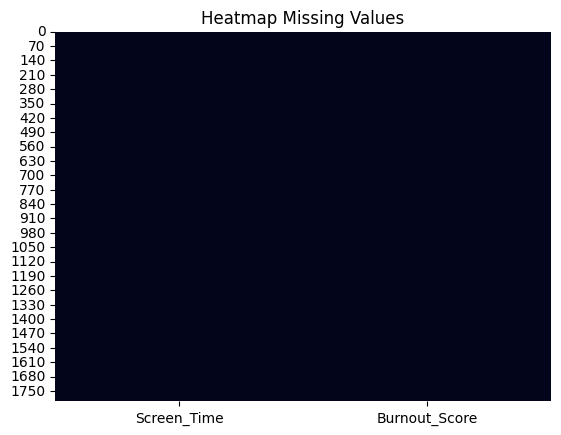

In [6]:
print("\n=== ANALISIS DATA HILANG ===\n")

total_missing = data.isna().sum().sum()
print("Total missing:", total_missing)

missing_per_var = data.isna().sum()
print("\nMissing per variabel:")
print(missing_per_var)

print("\nPersentase missing:")
print((data.isna().mean()*100).round(2))

# Visualisasi heatmap missing
plt.figure()
sns.heatmap(data.isna(), cbar=False)
plt.title("Heatmap Missing Values")
plt.show()

In [7]:
print("\n=== DETEKSI OUTLIER ===\n")

def detect_outliers(df):
    for col in df.columns:
        print(f"Analisis outlier untuk: {col}")

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_iqr = df[(df[col] < lower) | (df[col] > upper)]
        print("Jumlah outlier (IQR):", len(outlier_iqr))

        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outlier_z = np.sum(z_scores > 3)
        print("Jumlah outlier (Z-score > 3):", outlier_z)

        print("Batas bawah:", round(lower,2))
        print("Batas atas:", round(upper,2))
        print("-"*40)

detect_outliers(data)


=== DETEKSI OUTLIER ===

Analisis outlier untuk: Screen_Time
Jumlah outlier (IQR): 0
Jumlah outlier (Z-score > 3): 0
Batas bawah: 1.13
Batas atas: 17.42
----------------------------------------
Analisis outlier untuk: Burnout_Score
Jumlah outlier (IQR): 23
Jumlah outlier (Z-score > 3): 15
Batas bawah: -23.87
Batas atas: 107.44
----------------------------------------


In [8]:
def cap_outliers(df):
    df_copy = df.copy()

    for col in df_copy.columns:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_copy[col] = np.where(df_copy[col] < lower, lower, df_copy[col])
        df_copy[col] = np.where(df_copy[col] > upper, upper, df_copy[col])

    return df_copy

data_capped = cap_outliers(data)

In [9]:
X = data_capped["Screen_Time"]
Y = data_capped["Burnout_Score"]

# Tambahkan konstanta (intercept)
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print("\n=== RINGKASAN MODEL ===\n")
print(model.summary())


=== RINGKASAN MODEL ===

                            OLS Regression Results                            
Dep. Variable:          Burnout_Score   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     27.42
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.83e-07
Time:                        15:42:06   Log-Likelihood:                -8211.2
No. Observations:                1800   AIC:                         1.643e+04
Df Residuals:                    1798   BIC:                         1.644e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          32.8250  

In [11]:
from scipy.stats import pearsonr

variabel_x = data['Screen_Time'].values
variabel_y = data['Burnout_Score'].values

print("Data Screen Time:", variabel_x)
print("Data Burnout Score:", variabel_y)

# ================================
# HITUNG KORELASI PEARSON
# ================================

korelasi_pearson, p_value = pearsonr(variabel_x, variabel_y)

print(f"\nKoefisien Korelasi Pearson antara Screen Time dan Burnout Score: {korelasi_pearson:.3f}")
# Interpretasi kekuatan korelasi

if korelasi_pearson > 0.8:
    interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
    interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
    interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
    interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
    interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
    interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
    interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
    interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
    interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
    interpretasi = "Korelasi sangat lemah negatif"
else:
    interpretasi = "Tidak ada korelasi linier"

print(f"Interpretasi: {interpretasi}")

Data Screen Time: [11.86 10.33  8.92 ...  6.39 11.11  6.72]
Data Burnout Score: [19.17 29.7  32.93 ... 34.07 38.14 40.76]

Koefisien Korelasi Pearson antara Screen Time dan Burnout Score: 0.123
Interpretasi: Korelasi sangat lemah positif


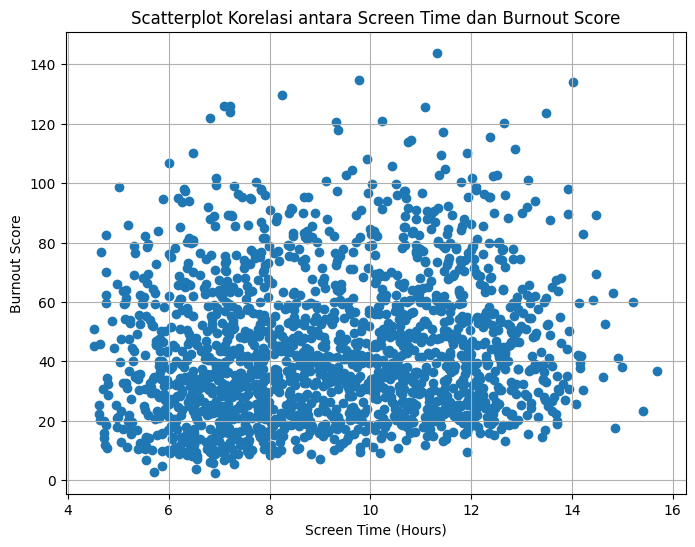

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(variabel_x, variabel_y)

plt.xlabel('Screen Time (Hours)')
plt.ylabel('Burnout Score')
plt.title('Scatterplot Korelasi antara Screen Time dan Burnout Score')
plt.grid(True)

plt.show()

In [13]:
alpha = 0.05

print(f"\nKoefisien Korelasi Pearson: {korelasi_pearson:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

if p_value < alpha:
    keputusan = "Tolak Hipotesis Nol (H0)"
    interpretasi_uji = """
Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier
yang signifikan antara Screen Time dan Burnout Score.
"""
else:
    keputusan = "Gagal Menolak Hipotesis Nol (H0)"
    interpretasi_uji = """
Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier
yang signifikan antara Screen Time dan Burnout Score.
"""

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")


Koefisien Korelasi Pearson: 0.123
P-value: 0.000
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: 
Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier
yang signifikan antara Screen Time dan Burnout Score.

